# L08. Deeper CNNs: VGG and ResNet

FashionMNIST를 224 x 224, 3채널 입력으로 변환한 뒤 `torchvision.models`의 VGG11과 ResNet18을 비교합니다.


## 1. 데이터 준비

사전 정의된 CNN 모델은 보통 큰 RGB 입력을 가정하므로 FashionMNIST 이미지를 224 x 224로 키우고 3채널로 복제합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
])

full_train = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

small_train = Subset(full_train, range(1000))
train_dataset, val_dataset = random_split(
    small_train,
    [800, 200],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(Subset(test_dataset, range(256)), batch_size=16, shuffle=False)

images, labels = next(iter(train_loader))
print('images shape:', tuple(images.shape))
print('labels shape:', tuple(labels.shape))


images shape: (16, 3, 224, 224)
labels shape: (16,)


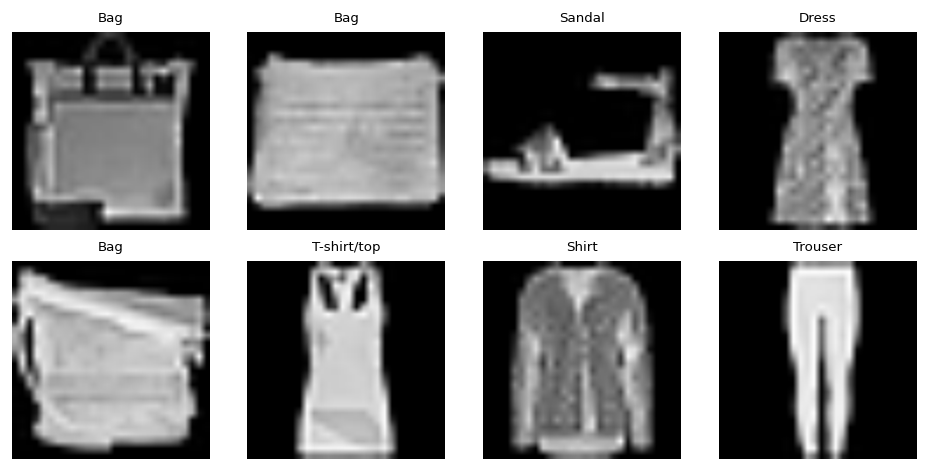

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.imshow(images[i].permute(1, 2, 0).numpy())
    ax.set_title(class_names[labels[i].item()], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 2. VGG 구조 보기

VGG는 비슷한 convolution block을 반복적으로 쌓는 구조입니다.


In [3]:
vgg = models.vgg11(weights=None)
print(vgg)
print('\nVGG classifier last layer:', vgg.classifier[-1])


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

## 3. ResNet 구조 보기

ResNet은 residual connection을 사용하는 구조입니다.

핵심 아이디어: `output = F(x) + x`


In [4]:
resnet = models.resnet18(weights=None)
print(resnet)
print('\nResNet fc layer:', resnet.fc)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 4. 분류층 바꾸기

FashionMNIST는 클래스 수가 10개이므로 마지막 층을 10차원 출력으로 바꿉니다.


In [5]:
def make_vgg_for_fashionmnist():
    model = models.vgg11(weights=None)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, 10)
    return model


def make_resnet_for_fashionmnist():
    model = models.resnet18(weights=None)

    for name, param in model.named_parameters():
        if not name.startswith('fc'):
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)
    return model


In [6]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_count += x.size(0)

    return total_loss / total_count, total_correct / total_count


def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=3):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_count += x.size(0)

        train_loss = total_loss / total_count
        train_acc = total_correct / total_count
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"epoch {epoch + 1:02d}: "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    return history


## 5. VGG와 ResNet 비교


In [7]:
criterion = nn.CrossEntropyLoss()

vgg_model = make_vgg_for_fashionmnist()
vgg_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, vgg_model.parameters()),
    lr=1e-3,
)
vgg_history = train_model(vgg_model, train_loader, val_loader, vgg_optimizer, criterion, epochs=3)

resnet_model = make_resnet_for_fashionmnist()
resnet_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-3,
)
resnet_history = train_model(resnet_model, train_loader, val_loader, resnet_optimizer, criterion, epochs=3)

print('VGG final val acc   :', round(vgg_history['val_acc'][-1], 4))
print('ResNet final val acc:', round(resnet_history['val_acc'][-1], 4))


epoch 01: train_loss=1.8038, train_acc=0.3825, val_loss=1.2343, val_acc=0.4650
epoch 02: train_loss=1.1226, train_acc=0.5487, val_loss=0.9430, val_acc=0.6700
epoch 03: train_loss=0.9819, train_acc=0.6325, val_loss=1.0317, val_acc=0.5950
epoch 01: train_loss=2.2782, train_acc=0.1725, val_loss=2.2848, val_acc=0.1700
epoch 02: train_loss=2.1338, train_acc=0.2112, val_loss=2.0492, val_acc=0.2300
epoch 03: train_loss=2.0752, train_acc=0.2400, val_loss=2.0418, val_acc=0.2500
VGG final val acc   : 0.595
ResNet final val acc: 0.25


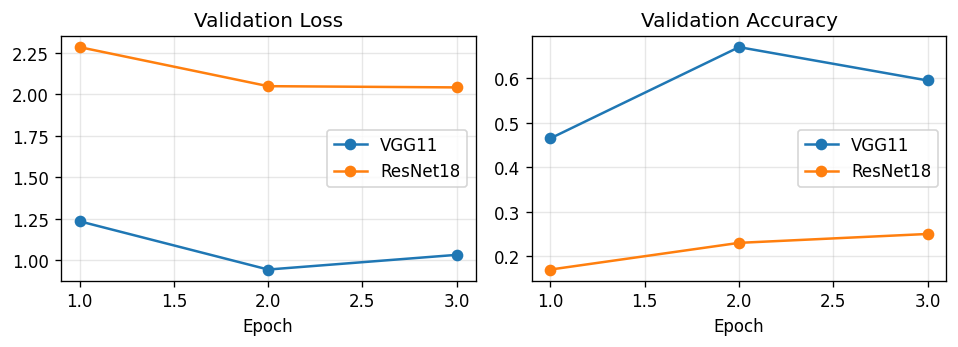

In [8]:
epochs = range(1, 4)

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.plot(epochs, vgg_history['val_loss'], marker='o', label='VGG11')
plt.plot(epochs, resnet_history['val_loss'], marker='o', label='ResNet18')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, vgg_history['val_acc'], marker='o', label='VGG11')
plt.plot(epochs, resnet_history['val_acc'], marker='o', label='ResNet18')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [9]:
for name, model in [('VGG11', vgg_model), ('ResNet18', resnet_model)]:
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    print(f'{name:8s} test loss = {test_loss:.4f}, test acc = {test_acc:.4f}')


VGG11    test loss = 1.0289, test acc = 0.5547
ResNet18 test loss = 1.9363, test acc = 0.3125


## 6. 핵심 정리

- VGG는 반복적인 convolution block을 쌓는 구조입니다.
- ResNet은 residual connection을 사용합니다.
- 마지막 분류층만 바꾸면 다른 데이터셋에도 적용할 수 있습니다.
- `torchvision.models`는 대표적인 CNN 구조를 바로 실험할 수 있게 해줍니다.


## 8. 연습문제 풀이

VGG/ResNet 추가 학습은 CPU 환경에서 오래 걸릴 수 있습니다. 기본 풀이 셀은 이미 학습한 `vgg_history`, `resnet_history`를 분석하고, 무거운 실험은 `RUN_SLOW_EXERCISES = True`로 바꾸면 실행되도록 구성했습니다.


### Exercise 1 풀이

이미 저장된 validation accuracy 기록을 비교하면 어느 모델이 더 빨리 올라가는지 확인할 수 있습니다.


In [10]:
def best_epoch(history):
    best_idx = int(np.argmax(history['val_acc']))
    return best_idx + 1, history['val_acc'][best_idx]

vgg_best_epoch, vgg_best_acc = best_epoch(vgg_history)
resnet_best_epoch, resnet_best_acc = best_epoch(resnet_history)

print(f'VGG11    best val acc={vgg_best_acc:.4f} at epoch {vgg_best_epoch}')
print(f'ResNet18 best val acc={resnet_best_acc:.4f} at epoch {resnet_best_epoch}')

if vgg_best_epoch < resnet_best_epoch:
    print('이 실행에서는 VGG11이 더 빨리 최고 validation accuracy에 도달했습니다.')
elif vgg_best_epoch > resnet_best_epoch:
    print('이 실행에서는 ResNet18이 더 빨리 최고 validation accuracy에 도달했습니다.')
else:
    print('이 실행에서는 두 모델이 같은 epoch에서 최고 validation accuracy에 도달했습니다.')


VGG11    best val acc=0.6700 at epoch 2
ResNet18 best val acc=0.2500 at epoch 3
이 실행에서는 VGG11이 더 빨리 최고 validation accuracy에 도달했습니다.


### Exercise 2 풀이

마지막 분류층만 학습하면 학습 파라미터가 적어서 빠르고 안정적입니다. 전체 파라미터를 학습하면 모델 전체가 FashionMNIST에 맞게 바뀔 수 있지만, 계산량이 커지고 작은 데이터에서는 overfitting 위험이 커집니다.


In [11]:
def make_vgg_full_for_fashionmnist():
    model = models.vgg11(weights=None)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, 10)
    return model


def make_resnet_full_for_fashionmnist():
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 10)
    return model


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

frozen_vgg = make_vgg_for_fashionmnist()
full_vgg = make_vgg_full_for_fashionmnist()
frozen_resnet = make_resnet_for_fashionmnist()
full_resnet = make_resnet_full_for_fashionmnist()

print('VGG frozen trainable params   :', count_trainable_parameters(frozen_vgg))
print('VGG full trainable params     :', count_trainable_parameters(full_vgg))
print('ResNet frozen trainable params:', count_trainable_parameters(frozen_resnet))
print('ResNet full trainable params  :', count_trainable_parameters(full_resnet))


VGG frozen trainable params   : 119586826
VGG full trainable params     : 128807306
ResNet frozen trainable params: 5130
ResNet full trainable params  : 11181642


### Exercise 3 풀이

epoch을 5로 늘리면 보통 training accuracy는 더 올라갑니다. validation accuracy는 좋아질 수도 있지만, 작은 데이터에서는 중간 이후 정체되거나 overfitting이 나타날 수 있습니다.


In [12]:
RUN_SLOW_EXERCISES = False

if RUN_SLOW_EXERCISES:
    vgg5_model = make_vgg_for_fashionmnist()
    vgg5_optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, vgg5_model.parameters()),
        lr=1e-3,
    )
    vgg5_history = train_model(vgg5_model, train_loader, val_loader, vgg5_optimizer, criterion, epochs=5)

    resnet5_model = make_resnet_for_fashionmnist()
    resnet5_optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, resnet5_model.parameters()),
        lr=1e-3,
    )
    resnet5_history = train_model(resnet5_model, train_loader, val_loader, resnet5_optimizer, criterion, epochs=5)

    print('VGG11 5-epoch final val acc   :', round(vgg5_history['val_acc'][-1], 4))
    print('ResNet18 5-epoch final val acc:', round(resnet5_history['val_acc'][-1], 4))
else:
    print('5 epoch 재학습은 시간이 걸릴 수 있어 기본 비활성화했습니다. 실행하려면 RUN_SLOW_EXERCISES=True로 바꾸세요.')


5 epoch 재학습은 시간이 걸릴 수 있어 기본 비활성화했습니다. 실행하려면 RUN_SLOW_EXERCISES=True로 바꾸세요.


### Exercise 4 풀이

`vgg16`과 `resnet34`도 마지막 분류층만 10개 클래스로 바꾸면 같은 방식으로 사용할 수 있습니다. 모델이 커지므로 학습 시간과 메모리 사용량이 늘어납니다.


In [13]:
def make_vgg16_for_fashionmnist():
    model = models.vgg16(weights=None)
    for param in model.features.parameters():
        param.requires_grad = False
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 10)
    return model


def make_resnet34_for_fashionmnist():
    model = models.resnet34(weights=None)
    for name, param in model.named_parameters():
        if not name.startswith('fc'):
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model

vgg16_probe = make_vgg16_for_fashionmnist()
resnet34_probe = make_resnet34_for_fashionmnist()

with torch.no_grad():
    print('VGG16 output shape   :', tuple(vgg16_probe(images[:2]).shape))
    print('ResNet34 output shape:', tuple(resnet34_probe(images[:2]).shape))

if RUN_SLOW_EXERCISES:
    vgg16_optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, vgg16_probe.parameters()),
        lr=1e-3,
    )
    resnet34_optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, resnet34_probe.parameters()),
        lr=1e-3,
    )
    vgg16_history = train_model(vgg16_probe, train_loader, val_loader, vgg16_optimizer, criterion, epochs=3)
    resnet34_history = train_model(resnet34_probe, train_loader, val_loader, resnet34_optimizer, criterion, epochs=3)


VGG16 output shape   : (2, 10)
ResNet34 output shape: (2, 10)


### Exercise 5 풀이

입력 크기를 96 x 96으로 줄여도 VGG와 ResNet의 forward pass는 가능합니다. VGG와 ResNet 모두 내부에 adaptive pooling 계열 처리가 있어 마지막 출력은 여전히 클래스 10개로 맞출 수 있습니다. 다만 입력이 작아지면 세부 정보가 줄어 validation accuracy가 달라질 수 있습니다.


In [14]:
x96 = torch.randn(2, 3, 96, 96)

vgg96 = make_vgg_for_fashionmnist()
resnet96 = make_resnet_for_fashionmnist()

with torch.no_grad():
    print('VGG11 96x96 output shape   :', tuple(vgg96(x96).shape))
    print('ResNet18 96x96 output shape:', tuple(resnet96(x96).shape))

transform_96 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
])
print('96x96 transform 예시:', transform_96)


VGG11 96x96 output shape   : (2, 10)
ResNet18 96x96 output shape: (2, 10)
96x96 transform 예시: Compose(
    Resize(size=(96, 96), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Lambda()
)
